 Import Libraries

In [89]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import f_oneway
from scipy.stats import chi2_contingency

 Load Dataset

In [91]:
df=sns.load_dataset("penguins")
df.head(100)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
95,Adelie,Dream,40.8,18.9,208.0,4300.0,Male
96,Adelie,Dream,38.1,18.6,190.0,3700.0,Female
97,Adelie,Dream,40.3,18.5,196.0,4350.0,Male
98,Adelie,Dream,33.1,16.1,178.0,2900.0,Female


5. Check Missing Values

In [92]:
df.isnull().sum()

,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11


 Dataset Information

In [93]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [47]:
df.columns

Index(['species', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm',
       'body_mass_g', 'sex'],
      dtype='object')

Missinل Values Check

Data Cleaning

In [114]:
df.dropna(inplace=True)

In [115]:
df.isnull().sum()

,0
species,0
island,0
bill_length_mm,0
bill_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,0
body_mass_category,0


 Convert Categorical Columns

Categorical variables were converted into category datatype for better memory efficiency and analysis.

In [116]:
df["species"] = df["species"].astype("category")
df["island"] = df["island"].astype("category")
df["sex"] = df["sex"].astype("category")

Summary Statistics

In [96]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,333.000000,333.000000,333.000000,333.000000
mean,43.992793,17.164865,200.966967,4207.057057
std,5.468668,1.969235,14.015765,805.215802
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.500000,17.300000,197.000000,4050.000000
75%,48.600000,18.700000,213.000000,4775.000000
max,59.600000,21.500000,231.000000,6300.000000


Histograms
Histograms show the distribution of numerical features. Most variables appear approximately normally distributed with moderate variation.

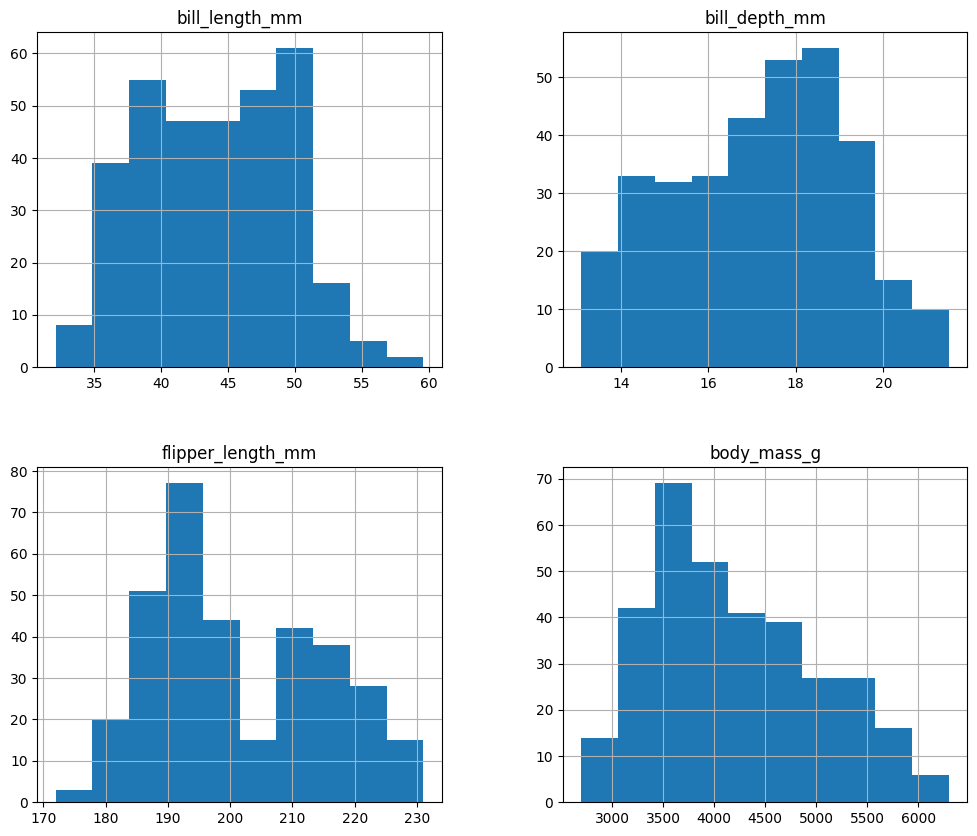

In [97]:
df.hist(figsize=(12,10))

plt.show()

 Pairplot
 The pairplot demonstrates visible separability among penguin species. Gentoo penguins generally have larger flipper lengths and body masses compared to other species.

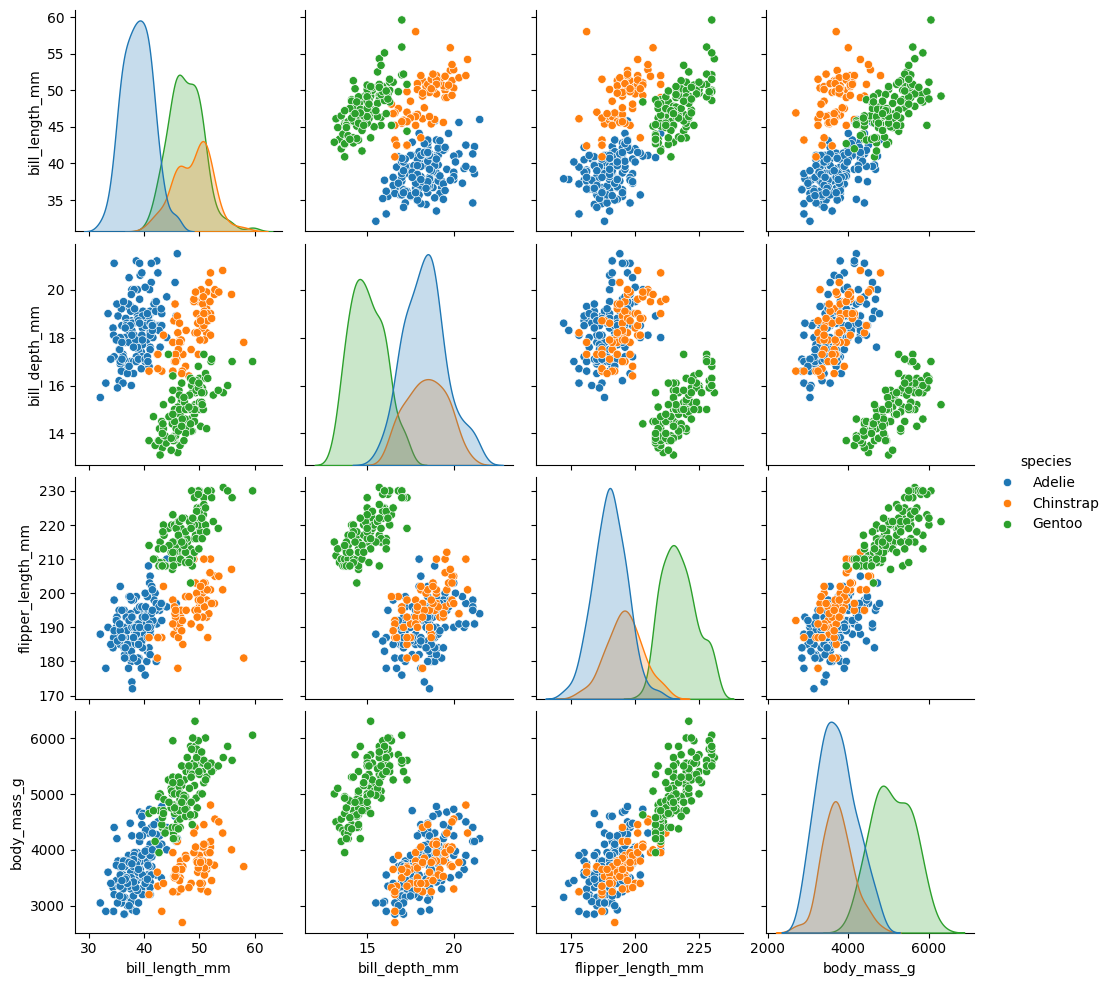

In [98]:
sns.pairplot(df, hue="species")

plt.show()

Boxplot — Flipper Length

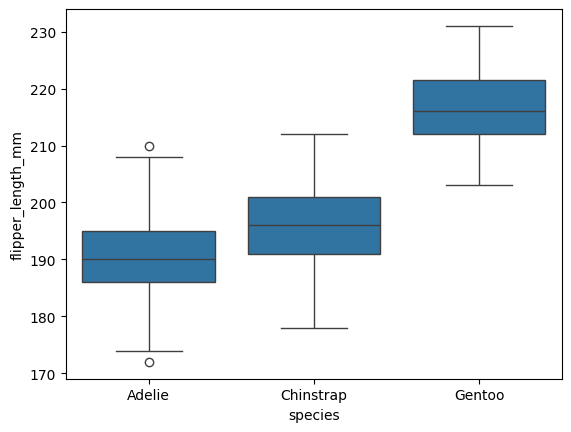

In [99]:
sns.boxplot(x="species", y="flipper_length_mm", data=df)

plt.show()

Boxplot — Bill Depth

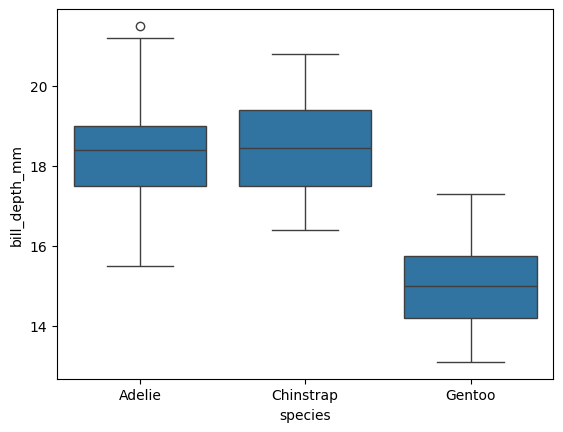

In [100]:
sns.boxplot(x="species", y="bill_depth_mm", data=df)

plt.show()

Boxplot — Body Mass

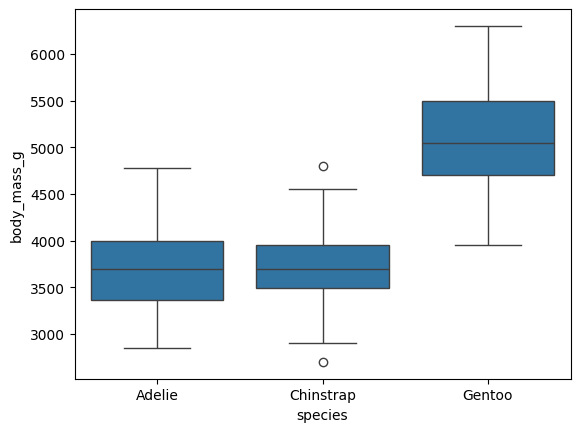

In [101]:
sns.boxplot(x="species", y="body_mass_g", data=df)

plt.show()

 Correlation Heatmap
 The heatmap shows strong positive correlation between body mass and flipper length, indicating that larger penguins tend to have longer flippers.

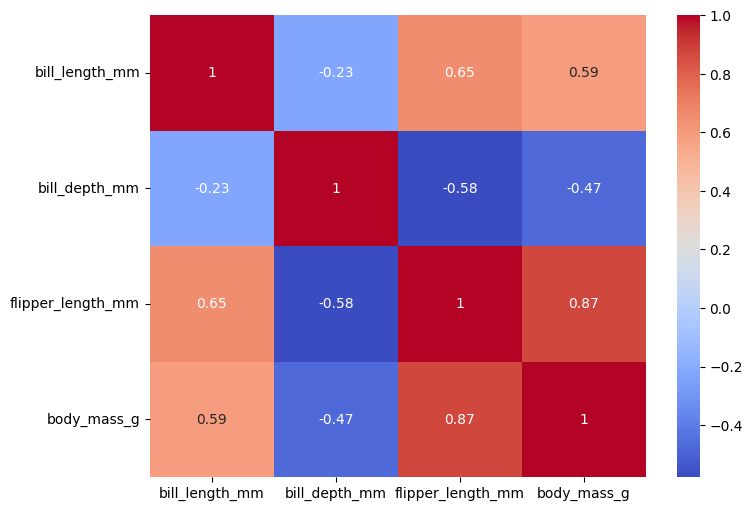

In [67]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.show()

H0: Mean flipper length is equal across all penguin species.

H1: At least one species has a different mean flipper length.

Split Dataset into Species Groups

In [103]:
adelie = df[df["species"] == "Adelie"]["flipper_length_mm"]

chinstrap = df[df["species"] == "Chinstrap"]["flipper_length_mm"]

gentoo = df[df["species"] == "Gentoo"]["flipper_length_mm"]

Compute Group Means

In [104]:
print("Adelie Mean:", adelie.mean())

print("Chinstrap Mean:", chinstrap.mean())

print("Gentoo Mean:", gentoo.mean())

Adelie Mean: 190.1027397260274
Chinstrap Mean: 195.8235294117647
Gentoo Mean: 217.23529411764707


Compute SSTotal, SSBetween, SSWithin

In [105]:


# Overall mean
overall_mean = df['flipper_length_mm'].mean()

# Group statistics
group_means = df.groupby('species')['flipper_length_mm'].mean()

group_sizes = df.groupby('species')['flipper_length_mm'].count()

# Total Sum of Squares (SSTotal)
ss_total = np.sum(
    (df['flipper_length_mm'] - overall_mean) ** 2
)

# Between-Group Sum of Squares (SSBetween)
ss_between = np.sum(
    group_sizes * (group_means - overall_mean) ** 2
)

# Within-Group Sum of Squares (SSWithin)
ss_within = np.sum(
    df.groupby('species').apply(
        lambda group: np.sum(
            (group['flipper_length_mm']
             - group['flipper_length_mm'].mean()) ** 2
        )
    )
)

print(f"SS Total: {ss_total:.2f}")

print(f"SS Between: {ss_between:.2f}")

print(f"SS Within: {ss_within:.2f}")

SS Total: 65218.64
SS Between: 50525.88
SS Within: 14692.75


/tmp/ipykernel_8707/3683049512.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_means = df.groupby('species')['flipper_length_mm'].mean()
/tmp/ipykernel_8707/3683049512.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_sizes = df.groupby('species')['flipper_length_mm'].count()
/tmp/ipykernel_8707/3683049512.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('species').apply(
/tmp/ipykernel_8

SS Total represents total variation in flipper length.

SS Between represents variation between penguin species.

SS Within represents variation inside each species group.

Compute Degrees of Freedom

In [106]:
# Number of groups
k = df['species'].nunique()

# Total observations
N = len(df)

# Degrees of Freedom
df_between = k - 1

df_within = N - k

df_total = N - 1

print(f"DF Between: {df_between}")

print(f"DF Within: {df_within}")

print(f"DF Total: {df_total}")

DF Between: 2
DF Within: 330
DF Total: 332


Compute Mean Squares

In [107]:
# Mean Square Between
ms_between = ss_between / df_between

# Mean Square Within
ms_within = ss_within / df_within

print(f"MS Between: {ms_between:.2f}")

print(f"MS Within: {ms_within:.2f}")

MS Between: 25262.94
MS Within: 44.52


Compute F-Statistic Manually

In [108]:
f_stat = ms_between / ms_within

print(f"F-Statistic: {f_stat:.2f}")

F-Statistic: 567.41


Perform ANOVA Using SciPy

In [109]:
anova_result = f_oneway(
    adelie,
    chinstrap,
    gentoo
)

print(
    f"F-statistic: {anova_result.statistic}"
)

print(
    f"P-value: {anova_result.pvalue}"
)

F-statistic: 567.4069920123421
P-value: 1.5874180554406345e-107


the null hypothesis is rejected.

This indicates statistically significant differences in flipper length among penguin species.

/tmp/ipykernel_8707/3884387868.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


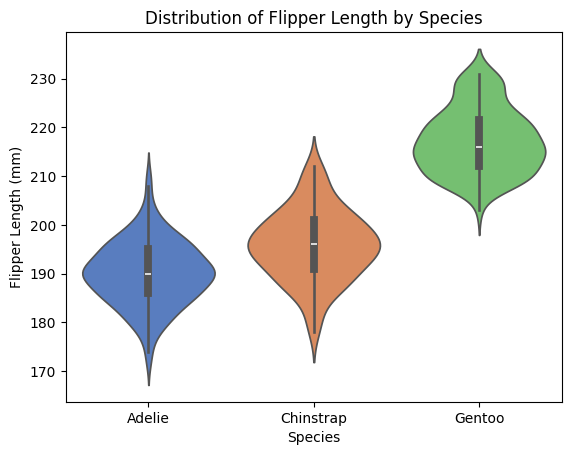

In [110]:
sns.violinplot(
    x='species',
    y='flipper_length_mm',
    data=df,
    palette='muted'
)

plt.title(
    "Distribution of Flipper Length by Species"
)

plt.xlabel("Species")

plt.ylabel("Flipper Length (mm)")

plt.show()

Create Body Mass Categories

In [111]:
df['body_mass_category'] = pd.cut(
    df['body_mass_g'],
    bins=[0, 3500, 4500, 7000],
    labels=['Light', 'Medium', 'Heavy']
)

Create Contingency Table

In [112]:
contingency_table = pd.crosstab(
    df['species'],
    df['body_mass_category']
)

contingency_table

body_mass_category,Light,Medium,Heavy
species,,,
Adelie,56,83,7
Chinstrap,19,47,2
Gentoo,0,16,103


In [118]:
chi2_stat, p_val, dof, expected = chi2_contingency(
    contingency_table
)

print(
    f"Chi-Square Statistic: {chi2_stat}"
)

print(
    f"P-value: {p_val}"
)
print(expected)

Chi-Square Statistic: 238.7987383714041
P-value: 1.6832050731363548e-50
[[32.88288288 64.01201201 49.10510511]
 [15.31531532 29.81381381 22.87087087]
 [26.8018018  52.17417417 40.02402402]]
